# 08 - Visualisation overfitting / underfitting

**Objectif :** diagnostiquer visuellement, fold par fold, si l'entrainement
a souffert de surapprentissage (overfitting) ou de sous-apprentissage
(underfitting), a partir des courbes `train_loss` / `valid_loss` deja
sauvegardees par le notebook 06.

**Source des donnees :** `data/results/training_leave_one_out_results.json`
(genere automatiquement a la fin du notebook 06 - lance ce dernier avant
celui-ci si le fichier n'existe pas).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = Path('../data/results')
RESULTS_FILE = RESULTS_DIR / 'training_leave_one_out_results.json'

## 1. Chargement des resultats

In [2]:
if not RESULTS_FILE.exists():
    raise FileNotFoundError(
        f"{RESULTS_FILE} introuvable. Lance d'abord le notebook 06 "
        "(entrainement complet leave-one-trace-out) pour generer ce fichier."
    )

with open(RESULTS_FILE) as f:
    all_results = json.load(f)

print(f"{len(all_results)} folds charges :")
for r in all_results:
    n_epochs = len(r["history"]["train_loss"])
    print(f"  {r['fold_valid_tracee']:10s} - {n_epochs} epochs, "
          f"meilleure valid_loss={r['best_valid_loss']:.4f} a l'epoch {r.get('best_epoch', '?')}")

4 folds charges :
  Tracee1    - 25 epochs, meilleure valid_loss=0.1832 a l'epoch 22
  Tracee2    - 25 epochs, meilleure valid_loss=0.1828 a l'epoch 18
  Tracee3    - 20 epochs, meilleure valid_loss=0.1615 a l'epoch 10
  Tracee4    - 25 epochs, meilleure valid_loss=0.1297 a l'epoch 18


## 2. Diagnostic automatique par fold

Principe utilise pour classer chaque fold :

- **Overfitting** : `train_loss` continue de baisser nettement pendant que
  `valid_loss` stagne ou remonte -> l'ecart (`gap = valid_loss - train_loss`)
  grandit sur la deuxieme moitie de l'entrainement.
- **Underfitting** : `train_loss` ET `valid_loss` restent elevees et proches
  l'une de l'autre jusqu'a la fin, sans vraiment descendre -> le modele n'a
  pas assez appris (pas assez d'epochs, capacite insuffisante, LR trop
  faible...).
- **Bon compromis** : `valid_loss` descend puis se stabilise pres de son
  minimum, avec un ecart train/valid qui reste raisonnable (quelques
  centiemes/dixiemes, pas un ecart qui explose).

In [3]:
def diagnostiquer_fold(result, seuil_gap_ratio=1.8, seuil_underfit=0.35):
    """Retourne un diagnostic texte pour un fold, base sur l'evolution de
    l'ecart train/valid et le niveau absolu de valid_loss."""
    train = np.array(result["history"]["train_loss"])
    valid = np.array(result["history"]["valid_loss"])
    n = len(train)
    if n < 4:
        return "Pas assez d'epochs pour diagnostiquer."

    gap = valid - train
    moitie = n // 2
    gap_debut = gap[:moitie].mean()
    gap_fin = gap[moitie:].mean()

    best_epoch = result.get("best_epoch", int(np.argmin(valid)) + 1)
    valid_min = valid.min()
    valid_fin = valid[-1]

    diagnostics = []

    # Overfitting : l'ecart train/valid grandit nettement sur la 2e moitie
    if gap_debut > 0 and gap_fin > seuil_gap_ratio * max(gap_debut, 1e-6):
        diagnostics.append(
            f"OVERFITTING : l'ecart valid-train grandit nettement "
            f"({gap_debut:.3f} -> {gap_fin:.3f}). Le modele memorise "
            f"l'entrainement au-dela de l'epoch {best_epoch} sans mieux "
            f"generaliser."
        )
    # Underfitting : valid_loss reste elevee et n'a pas vraiment convergé
    elif valid_min > seuil_underfit:
        diagnostics.append(
            f"UNDERFITTING possible : la meilleure valid_loss ({valid_min:.3f}) "
            f"reste assez elevee, et l'ecart train/valid est faible "
            f"({gap_fin:.3f}) -> le modele n'a peut-etre pas assez appris "
            f"(plus d'epochs, LR plus eleve, ou capacite/donnees a revoir)."
        )
    else:
        diagnostics.append(
            f"OK : convergence raisonnable, meilleure valid_loss={valid_min:.3f} "
            f"a l'epoch {best_epoch}, ecart train/valid contenu (fin={gap_fin:.3f})."
        )

    if valid_fin > valid_min * 1.15:
        diagnostics.append(
            f"  (remarque : valid_loss finale ({valid_fin:.3f}) nettement pire "
            f"que le minimum ({valid_min:.3f}) -> l'early stopping/checkpoint "
            f"au meilleur epoch est important ici, ne pas garder le modele final.)"
        )

    return " ".join(diagnostics)


for r in all_results:
    diag = diagnostiquer_fold(r)
    print(f"[{r['fold_valid_tracee']}] {diag}\n")

[Tracee1] OK : convergence raisonnable, meilleure valid_loss=0.183 a l'epoch 22, ecart train/valid contenu (fin=0.103).   (remarque : valid_loss finale (0.211) nettement pire que le minimum (0.183) -> l'early stopping/checkpoint au meilleur epoch est important ici, ne pas garder le modele final.)

[Tracee2] OK : convergence raisonnable, meilleure valid_loss=0.183 a l'epoch 18, ecart train/valid contenu (fin=0.100).

[Tracee3] OVERFITTING : l'ecart valid-train grandit nettement (0.033 -> 0.068). Le modele memorise l'entrainement au-dela de l'epoch 10 sans mieux generaliser.

[Tracee4] OVERFITTING : l'ecart valid-train grandit nettement (0.000 -> 0.031). Le modele memorise l'entrainement au-dela de l'epoch 18 sans mieux generaliser.



## 3. Courbes train / valid par fold (avec zone de surapprentissage)

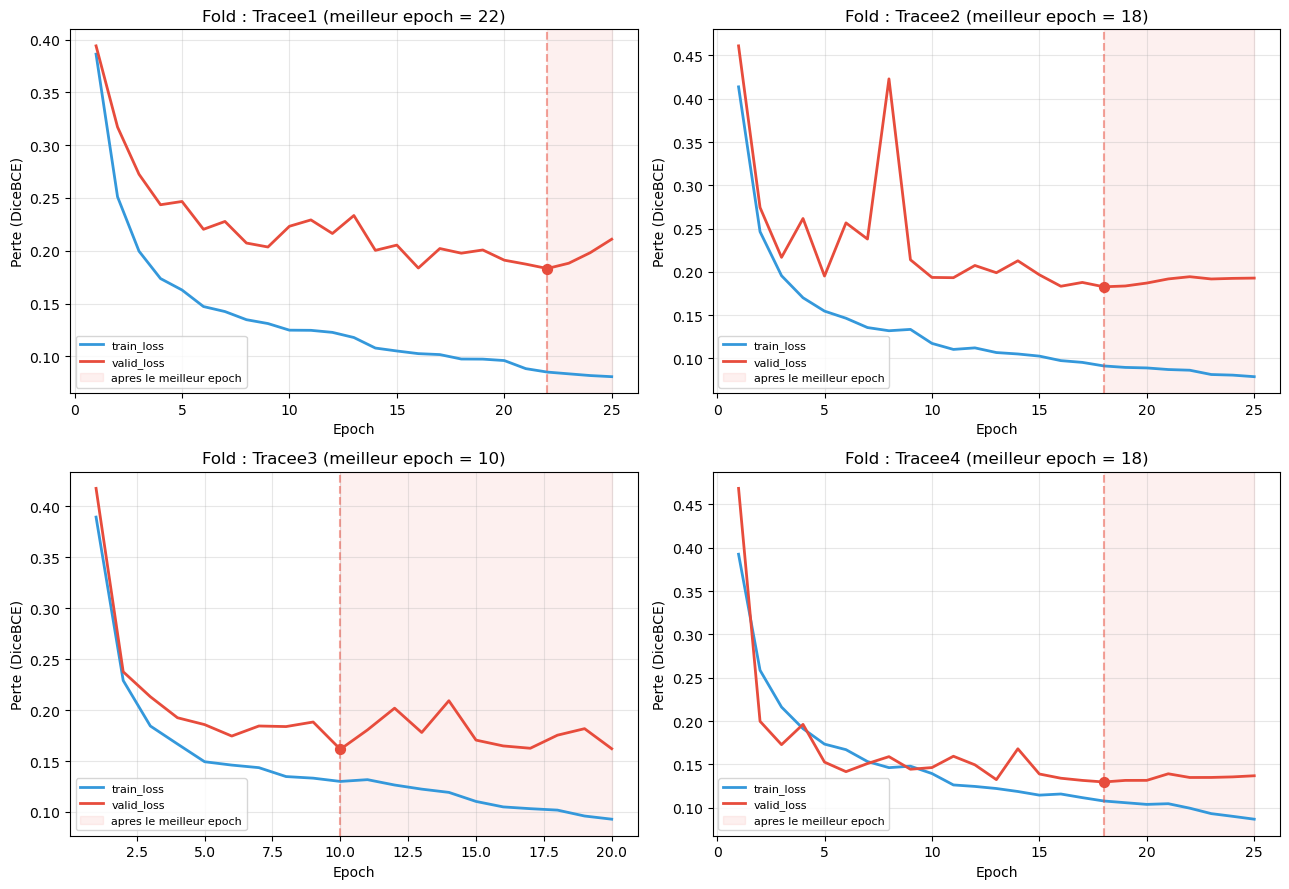

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, r in zip(axes, all_results):
    train = r["history"]["train_loss"]
    valid = r["history"]["valid_loss"]
    epochs = list(range(1, len(train) + 1))
    best_epoch = r.get("best_epoch", int(np.argmin(valid)) + 1)

    ax.plot(epochs, train, label="train_loss", color="#3498db", linewidth=2)
    ax.plot(epochs, valid, label="valid_loss", color="#e74c3c", linewidth=2)

    # zone apres le meilleur epoch = zone de surapprentissage potentiel
    if best_epoch < len(epochs):
        ax.axvspan(best_epoch, len(epochs), color="#e74c3c", alpha=0.08,
                   label="apres le meilleur epoch")

    ax.axvline(best_epoch, color="#e74c3c", linestyle="--", alpha=0.5)
    ax.scatter([best_epoch], [valid[best_epoch - 1]], color="#e74c3c", zorder=5, s=50)

    ax.set_title(f"Fold : {r['fold_valid_tracee']} (meilleur epoch = {best_epoch})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Perte (DiceBCE)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / "courbes_train_valid_par_fold.png", dpi=120)
plt.show()

## 4. Ecart train/valid (`gap`) au fil des epochs

Une autre facon de lire le meme phenomene : si le `gap` (valid - train)
grandit avec le temps, c'est un signal direct de surapprentissage, meme
quand `valid_loss` ne remonte pas franchement (elle stagne juste, ce qui est
plus subtil a voir sur les courbes brutes).

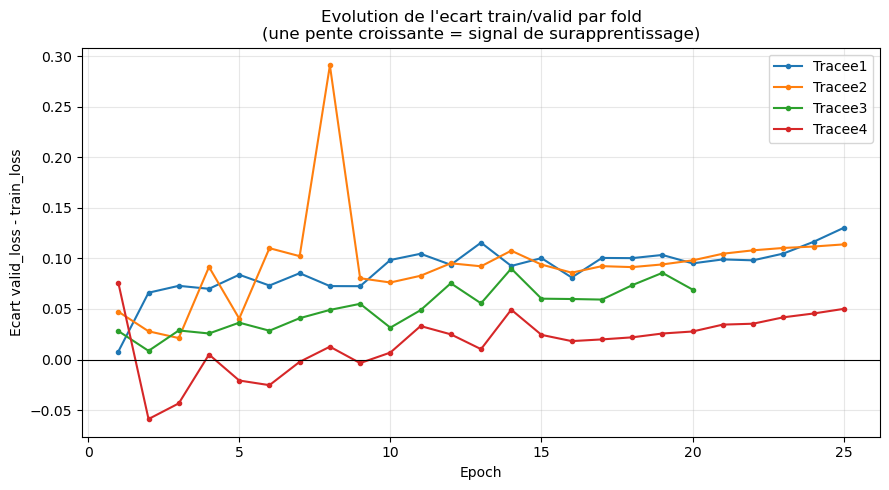

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

for r in all_results:
    train = np.array(r["history"]["train_loss"])
    valid = np.array(r["history"]["valid_loss"])
    gap = valid - train
    epochs = list(range(1, len(gap) + 1))
    ax.plot(epochs, gap, marker="o", markersize=3, label=r["fold_valid_tracee"])

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Ecart valid_loss - train_loss")
ax.set_title("Evolution de l'ecart train/valid par fold\n"             "(une pente croissante = signal de surapprentissage)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ecart_train_valid.png", dpi=120)
plt.show()

## 5. Guide de lecture

| Ce que tu observes | Interpretation | Action possible |
|---|---|---|
| `train_loss` continue de baisser, `valid_loss` stagne ou remonte, ecart qui grandit | Overfitting | Reduire la patience, augmenter le weight decay, plus de donnees/augmentation, reduire la capacite du modele |
| `train_loss` et `valid_loss` restent elevees et proches, plateau precoce | Underfitting | Plus d'epochs, LR plus eleve (voir notebook 07), modele plus grand, verifier que les donnees/labels sont corrects |
| `valid_loss` descend puis se stabilise pres de son minimum, ecart raisonnable | Bon compromis | Rien a changer - le checkpoint au meilleur epoch est fiable |
| Courbes tres bruitees, `valid_loss` oscille fort d'une epoch a l'autre | Possible instabilite d'optimisation | Reduire le LR, augmenter le batch size si la memoire le permet, verifier la taille du jeu de validation (petits sets = plus de bruit) |

D'apres les resultats du notebook 06, chaque fold a affiche un debut
d'overfitting apres son meilleur epoch (train_loss continuant de baisser
alors que valid_loss stagnait) - c'est exactement pour ca que l'early
stopping (`PATIENCE`) et la sauvegarde du meilleur checkpoint uniquement
sont importants dans ce projet : le modele final utilise n'est jamais le
dernier de l'entrainement, mais celui du meilleur epoch.